In [1]:
import os 
import numpy as np
import h5py as h5
import MDAnalysis as mda
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import pickle as pkl

from MDAnalysis.transformations import unwrap, center_in_box, wrap
from MDAnalysis.analysis import align

os.chdir('/media/volume/Orai1_rep0/Orai1_analysis')

/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


### Clustering

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [3]:
def clustering(data, min_cluster_size=50):
    cluster = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=None,
        cluster_selection_method='eom'
    )
    return cluster.fit_predict(data)

def plot_ic_clusters(ICs, labels, alpha=0.5, size=6):
    """
    ICs    : (n_frames, >=2) array, e.g. tICA output
    labels : (n_frames,) cluster labels from HDBSCAN
    """

    ICs = np.asarray(ICs)
    labels = np.asarray(labels)

    if ICs.shape[1] < 2:
        raise ValueError("Need at least 2 ICs")

    plt.figure(figsize=(6,5))

    unique = np.unique(labels)

    for lab in unique:
        mask = labels == lab

        if lab == -1:   # noise
            plt.scatter(ICs[mask,0], ICs[mask,1],
                        s=size, c='lightgray',
                        alpha=0.25, label='noise')
        else:
            plt.scatter(ICs[mask,0], ICs[mask,1],
                        s=size, alpha=alpha,
                        label=f'C{lab}')

    plt.xlabel("IC1")
    plt.ylabel("IC2")
    plt.title("HDBSCAN clusters projected onto IC space")
    plt.legend(markerscale=3, bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()

def readh5(fn):
    tica = h5.File(fn, 'r')
    read = []
    keys = sorted([k for k in tica.keys()])
    for k in keys:
        read.append(tica[k][:])
    read = np.concatenate(read)
    return read

PCA3 = readh5('analysis/WT_refined_loop/structural/Rep-3/pca.h5')
PCA1 = readh5('analysis/WT_refined_loop/structural/Rep-1/pca.h5')
PCA2 = readh5('analysis/WT_refined_loop//structural/Rep-2/pca.h5')


In [9]:
PCA3.shape

(5388, 1673)

In [4]:
n = 5000
reps = [PCA1, PCA2, PCA3]
reps_ = ['rep1', 'rep2', 'rep3']
j = 0
k = 2
print (f'Correlation between {reps_[j]} and {reps_[k]}')
for i in range(5):
    corr = np.corrcoef(reps[j][:n, i], reps[k][:n, i])[0, 1]
    print(f"Dimension {i+1} correlation: {corr:.4f}")


Correlation between rep1 and rep3
Dimension 1 correlation: -0.9871
Dimension 2 correlation: 0.9595
Dimension 3 correlation: -0.8388
Dimension 4 correlation: -0.6596
Dimension 5 correlation: 0.6982


In [5]:
# Copy arrays so we don't modify originals
n = 5000
rep1 = PCA1[:n, :].copy()
rep2 = PCA2[:n, :].copy()
rep3 = PCA3[:n, :].copy()

# Align sign of rep1 and rep2 to rep0
for i in range(2):
    if np.corrcoef(rep1[:, i], rep2[:, i])[0, 1] < 0:
        rep2[:, i] *= -1
    if np.corrcoef(rep1[:, i], rep3[:, i])[0, 1] < 0:
        rep3[:, i] *= -1

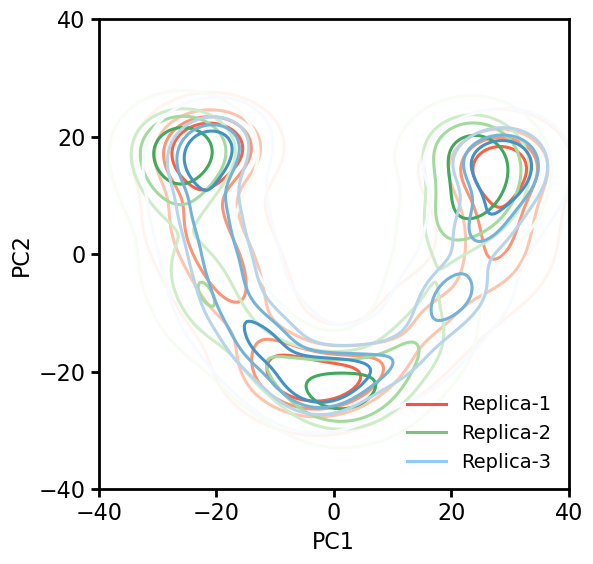

In [6]:

fig, ax = plt.subplots(figsize=(6,6))

colors = {
    "rep1": "red",   # red
    "rep2": "green",   # green
    "rep3": "blue",    # purple
    "rep4": "black"
}
lv = 5

sns.kdeplot(x=rep1[:,0], y=rep1[:,1], levels=lv, ax=ax,
            color=colors["rep1"], cmap = "Reds", linewidths=2.2)

sns.kdeplot(x=rep2[:,0], y=rep2[:,1], levels=lv, ax=ax,
            color=colors["rep2"], cmap = "Greens", linewidths=2.2)

sns.kdeplot(x=rep3[:,0], y=rep3[:,1], levels=lv, ax=ax,
            color=colors["rep3"], cmap = "Blues", linewidths=2.2)

ft = 16
ax.set_xlabel('PC1', fontsize=ft)
ax.set_ylabel('PC2', fontsize=ft)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=ft, width=2, length=6)
ax.tick_params(axis='both', which='minor', width=1.5, length=4)

# Spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Axis limits
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)

# Fixed ticks
ticks = [-40, -20, 0, 20, 40]
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_aspect('equal', adjustable='box')

# Proper legend
handles = [
    Line2D([0], [0], color=colors["rep1"], lw=2.2, label="Replica-1", alpha = 0.7),
    Line2D([0], [0], color=colors["rep2"], lw=2.2, label="Replica-2", alpha = 0.5),
    Line2D([0], [0], color="#5CB6F9", lw=2.2, label="Replica-3", alpha = 0.7)
]

ax.legend(handles=handles, fontsize=14, frameon=False, loc = 'lower right')

plt.tight_layout()
#plt.savefig('analysis/PC1vs2.4reps.png')
plt.show()


In [14]:
rep3.shape

(5000, 1673)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
import hdbscan
start = 2000
n = 2
reps = [rep1, rep2, rep3]
raw_dtrajs = clustering(reps[n][start:, :8], min_cluster_size=5)
mask = raw_dtrajs != -1 #remove labels -1 or noise
X_train = reps[n][start:][mask]
y_train = raw_dtrajs[mask]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train) #train model using the strided labeled data

# === Predict full data labels
tc_labels_full = knn.predict(reps[n][start:])
print (max(raw_dtrajs))
os.makedirs('analysis/WT_refined_loop/clustering/200.500ns', exist_ok=True)
np.save(f'analysis/WT_refined_loop/clustering/200.500ns/dtrajs-rep{n+1}.200-500.npy', tc_labels_full)

14


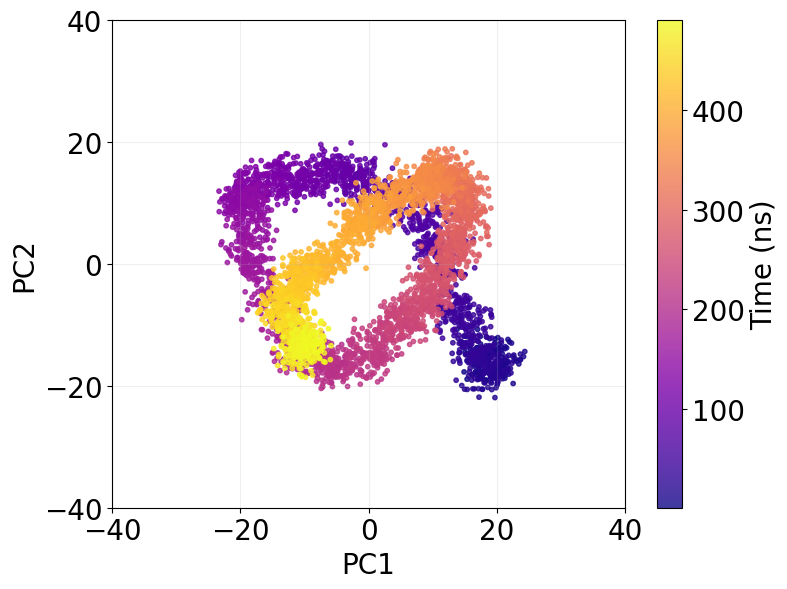

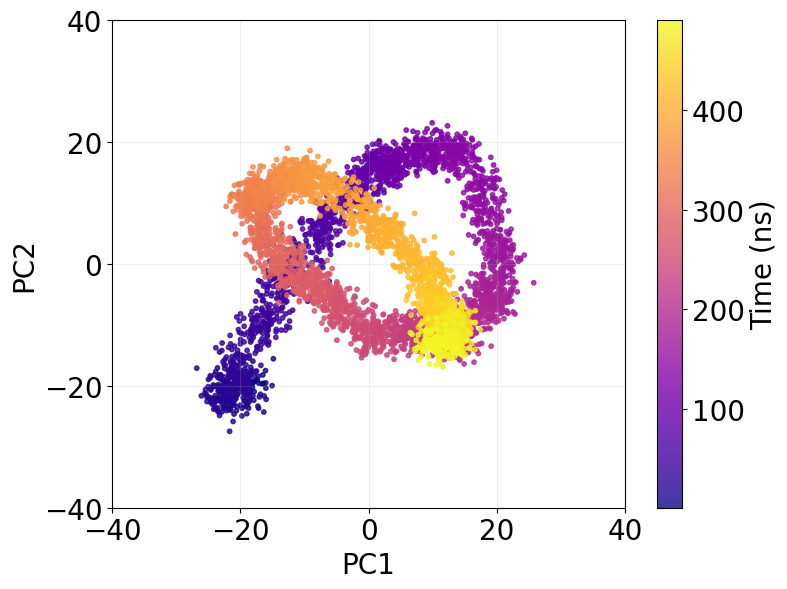

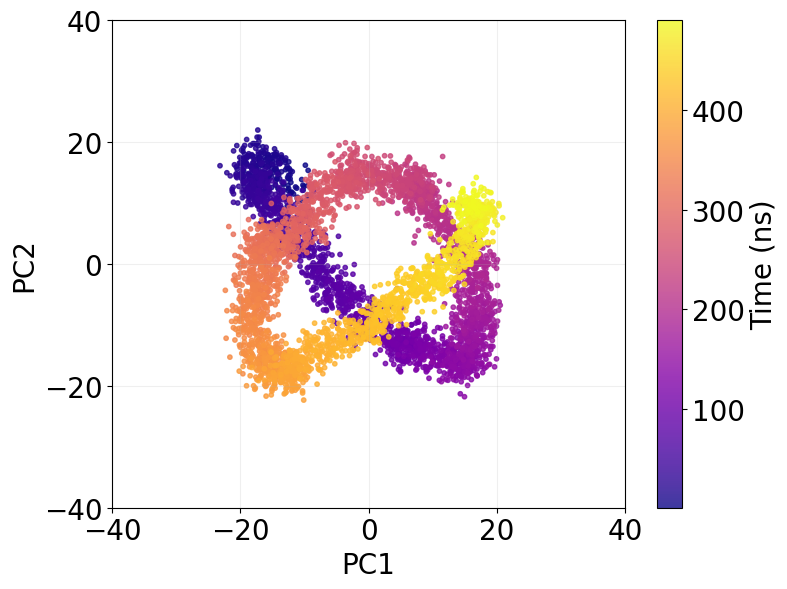

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_time_projection(pca_data, total_ns=490, start_ns=1, end_ns=490, replica_label="Rep-1", ft = 20):
    n_frames = len(pca_data)
    time_array = np.linspace(0, total_ns, n_frames)
    
    # 1. Create the Time Window Mask
    window_mask = (time_array >= start_ns) & (time_array <= end_ns)
    window_data = pca_data[window_mask]
    
    plt.figure(figsize=(8, 6))
    
    # 2. Plot the FULL trajectory as a gray "background" to see the whole space
    #plt.scatter(pca_data[:, 0], pca_data[:, 1], c='lightgray', s=3, alpha=0.2, label='Full Trajectory (0-500ns)')
    
    # 3. Overlay the 300-500ns window with a color gradient
    # This shows the "direction" of motion in the final window
    sc = plt.scatter(window_data[:, 2], window_data[:, 3], 
                     c=time_array[window_mask], cmap='plasma', 
                     s=10, alpha=0.8, label=f'Window ({start_ns}-{end_ns}ns)')
    
    # Add a colorbar specifically for the 300-500ns window
    cbar = plt.colorbar(sc)
    cbar.set_label(f'Time (ns)', fontsize=ft)
    cbar.ax.tick_params(labelsize=ft)
    ticks = [-40, -20, 0, 20, 40]
    plt.xticks(ticks, fontsize=ft)
    plt.yticks(ticks, fontsize=ft)
    plt.xlabel("PC1", fontsize = ft)
    plt.ylabel("PC2", fontsize = ft)
    # plt.title(f"{replica_label}: {start_ns}-{end_ns}ns Projection onto Full Space")
    # plt.legend(loc='lower right', markerscale=2)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Run for each replica
plot_pca_time_projection(rep1, replica_label="Replica 1")
plot_pca_time_projection(rep2, replica_label="Replica 2")
plot_pca_time_projection(rep3, replica_label="Replica 3")

#### Find medoids

In [20]:
# Finding of medoids as representatives
from sklearn.metrics import pairwise_distances_argmin_min

def cluster_representatives(data, labels, metric='euclidean'):
    """
    data   : (n_frames, n_features) ICs / PCA / tICA / features
    labels : cluster labels from HDBSCAN

    returns
        dict {cluster_id: representative_index}
    """

    data = np.asarray(data)
    labels = np.asarray(labels)

    reps = {}

    for lab in np.unique(labels):

        if lab == -1:  # skip noise
            continue

        idx = np.where(labels == lab)[0]
        cluster_data = data[idx]

        # centroid
        center = cluster_data.mean(axis=0, keepdims=True)

        # closest point to centroid (medoid)
        rep_local, _ = pairwise_distances_argmin_min(
            center, cluster_data, metric=metric
        )

        reps[lab] = idx[rep_local[0]]

    return reps
dtraj1 = np.load('analysis/WT_refined_loop/clustering/200.500ns/dtrajs-rep1.200-500.npy')
dtraj2 = np.load('analysis/WT_refined_loop/clustering/200.500ns/dtrajs-rep2.200-500.npy')
dtraj3 = np.load('analysis/WT_refined_loop/clustering/200.500ns/dtrajs-rep3.200-500.npy')
reps1 = cluster_representatives(rep1[2000:], dtraj1)
reps2 = cluster_representatives(rep2[2000:], dtraj2)
reps3 = cluster_representatives(rep3[2000:], dtraj3)
print (f'Representatives for each cluster as the medoid for rep1: {reps1}')
print (f'Representatives for each cluster as the medoid for rep2: {reps2}')
print (f'Representatives for each cluster as the medoid for rep3: {reps3}')


Representatives for each cluster as the medoid for rep1: {0: 499, 1: 1973, 2: 2700, 3: 2857, 4: 1780, 5: 1901, 6: 1482, 7: 1046, 8: 1266, 9: 1637, 10: 1699, 11: 2014, 12: 2034, 13: 2143, 14: 2557, 15: 2477, 16: 2284, 17: 2377}
Representatives for each cluster as the medoid for rep2: {0: 2834, 1: 26, 2: 235, 3: 90, 4: 368, 5: 620, 6: 816, 7: 904, 8: 991, 9: 1092, 10: 1186, 11: 1254, 12: 1573, 13: 1367, 14: 1296}
Representatives for each cluster as the medoid for rep3: {0: 393, 1: 776, 2: 1303, 3: 1001, 4: 1169, 5: 1406, 6: 1960, 7: 1664, 8: 1842, 9: 1779, 10: 2896, 11: 2167, 12: 2472, 13: 2731, 14: 2817}


In [21]:
# Writing representatives as medoids
source = '/media/volume/Orai1_rep0/Orai1_analysis'
psf = os.path.join(
    source,
    'system/WT_refined_loop/step5_input.psf')

replica = 1
outdir = f'analysis/WT_refined_loop/Rec-medoids/Rep-{replica}/200.500ns/whole'
os.makedirs(outdir, exist_ok=True)
traj = sorted(glob.glob(f'postprocessed_simulation/WT_refined_loop/Rep-{replica}/whole/TRAJ00*.xtc'))
u = mda.Universe(psf, traj)
atoms = u.select_atoms('all')

# reps = {cluster_id: frame_index}
reps = [reps1, reps2, reps3]
for cid, frame in reps[replica-1].items():
    u.trajectory[2000 + frame]          # jump directly

    outname = f"{outdir}/{2000 + frame:04d}.pdb"
    atoms.write(outname)

print("Done writing representatives.")


/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1080: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1080: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1080: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn("Found no information for attr: '{}'"
/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1080: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/home/exouser/miniconda3/envs/openff/lib/python

Done writing representatives.


In [22]:
# Writing representatives as medoids
source = '/media/volume/Orai1_rep0/Orai1_analysis'
psf = os.path.join(
    source,
    'system/WT_refined_loop/step5_input.psf')

replica = 2
outdir = f'analysis/WT_refined_loop/Rec-medoids/Rep-{replica}/200.500ns/whole'
os.makedirs(outdir, exist_ok=True)
traj = sorted(glob.glob(f'postprocessed_simulation/WT_refined_loop/Rep-{replica}/whole/TRAJ00*.xtc'))
u = mda.Universe(psf, traj)
atoms = u.select_atoms('all')

# reps = {cluster_id: frame_index}
reps = [reps1, reps2, reps3]
for cid, frame in reps[replica-1].items():
    u.trajectory[2000 + frame]          # jump directly

    outname = f"{outdir}/{2000 + frame:04d}.pdb"
    atoms.write(outname)

print("Done writing representatives.")


Done writing representatives.


In [23]:
# Writing representatives as medoids
source = '/media/volume/Orai1_rep0/Orai1_analysis'
psf = os.path.join(
    source,
    'system/WT_refined_loop/step5_input.psf')

replica = 3
outdir = f'analysis/WT_refined_loop/Rec-medoids/Rep-{replica}/200.500ns/whole'
os.makedirs(outdir, exist_ok=True)
traj = sorted(glob.glob(f'postprocessed_simulation/WT_refined_loop/Rep-{replica}/whole/TRAJ00*.xtc'))
u = mda.Universe(psf, traj)
atoms = u.select_atoms('all')

# reps = {cluster_id: frame_index}
reps = [reps1, reps2, reps3]
for cid, frame in reps[replica-1].items():
    u.trajectory[2000 + frame]          # jump directly

    outname = f"{outdir}/{2000 + frame:04d}.pdb"
    atoms.write(outname)

print("Done writing representatives.")


Done writing representatives.


In [25]:
def fix_pdb(infile, outfile):
    """
    Combined PDB fixer:
      1. OT1 -> O, OT2 -> OXT + TER insertion
      2. Chain ID derived from segid (PROA -> A)
      3. Element column populated from atom name
      4. CHARMM histidine names -> FoldX/PDB standard (HSD/HSE -> HIS, HSP -> HIP)
    """
    # RESNAME_MAP = {
    #     "HSD": "HIS",
    #     "HSE": "HIS",
    #     "HSP": "HIP",
    # }

    def get_element(atom_name):
        name = atom_name.strip()
        if len(name) == 1:
            return name
        if name[1].islower():
            return name[:2]
        return name[0]

    with open(infile) as f:
        lines = f.readlines()

    out_lines = []
    i = 0
    while i < len(lines):
        line = lines[i]

        if not (line.startswith("ATOM") or line.startswith("HETATM")):
            out_lines.append(line)
            i += 1
            continue

        # --- Step 1: fix terminal oxygen names ---
        atom_name = line[12:16].strip()
        if atom_name == "OT1":
            line = line[:12] + " O  " + line[16:]
        elif atom_name == "OT2":
            line = line[:12] + " OXT" + line[16:]

        # --- Step 4: fix CHARMM histidine residue names ---
        # resname = line[17:20].strip()
        # if resname in RESNAME_MAP:
        #     new_resname = f"{RESNAME_MAP[resname]:<3s}"
        #     line = line[:17] + new_resname + line[20:]

        # --- Step 2: fix chain ID from segid (ATOM lines only) ---
        if line.startswith("ATOM"):
            atom_name_field = line[12:16]
            resid           = line[22:26]
            segid_full      = line[72:76].strip()
            chainID         = line[21]

            if segid_full.startswith("PRO") and len(segid_full) == 4:
                new_chain = segid_full[-1]
            else:
                new_chain = chainID

            new_segid = f"{new_chain:<4s}"
            element   = get_element(atom_name_field).rjust(2)

            line = (
                f"{line[:21]}{new_chain}"
                f"{resid}{line[26:30]}"
                f"{line[30:54]}{line[54:60]}{line[60:66]}      "
                f"{new_segid}{element}\n"
            )

        out_lines.append(line)

        # --- Step 3: insert TER after OT2 ---
        if atom_name == "OT2":
            out_lines.append("TER\n")

        i += 1

    with open(outfile, "w") as f:
        f.writelines(out_lines)

In [28]:
rep = 3
outdir = f'analysis/WT_refined_loop/Rec-medoids/Rep-{rep}/200.500ns/whole'
pdbs = glob.glob(os.path.join(outdir, '*.pdb'))
for f in pdbs:
    name = os.path.basename(f).split('.')[0]
    out = os.path.join(outdir, f'tmp.{name}.pdb')
    fix_pdb(f, out)
    os.remove(f)
    os.rename(out, f)

In [93]:
replica = 3
pdbs = glob.glob(f'analysis/WT_refined_loop/Rec-medoids/Rep-{replica}/full/protein/*_Repair.pdb')

targetdir = f'analysis/WT_refined_loop/Rec-medoids/Rep-{replica}/full/foldx'
os.makedirs(targetdir, exist_ok=True)
for fn in pdbs:
    name = os.path.basename(fn).split('_')[0]
    newfn = os.path.join(targetdir, f'{name}.pdb')
    os.rename(fn, newfn)

### Snap selection

In [1]:
import os
import glob
import MDAnalysis as mda

import numpy as np

os.chdir('/media/volume/Orai1_rep0/Orai1_analysis')

In [2]:
pdb = 'postprocessed_simulation/WT_refined_loop/Rep-3/protmem/TRAJ000.pdb'
trajs = sorted (glob.glob('postprocessed_simulation/WT_refined_loop/Rep-3/protmem/TRAJ00*.part00*.xtc'))
sim = mda.Universe(pdb, trajs)
sim.trajectory

In [7]:
print(sim.trajectory.n_frames, sim.atoms.n_atoms)
print(sim.trajectory[0].time, sim.trajectory[1].time, sim.trajectory[-1].time)  # ps

43068 154231
2260.0 2270.0 432930.0


In [20]:
import os
prot = sim.select_atoms('all')
os.makedirs('analysis/WT_refined_loop/Rep-3/protmem/snapshots', exist_ok=True)

tar_ = 'analysis/WT_refined_loop/Rep-3/protmem/snapshots'
T0, DT = 2260.0, 10.0          # ps: time of frame 0, ps per frame
f = lambda t_ns: int(round((t_ns * 1000 - T0) / DT))
start = 400
end = 430

for i in range(f(start), f(end) + 1, 100):
    sim.trajectory[i]
    t_ns = sim.trajectory.ts.time / 1000.0
    prot.write(f'{tar_}/{int(t_ns):04d}.pdb')
    print(i, f'{t_ns:.2f} ns')

/home/exouser/miniconda3/envs/openff/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1080: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"


39774 400.00 ns
39874 401.00 ns
39974 402.00 ns
40074 403.00 ns
40174 404.00 ns
40274 405.00 ns
40374 406.00 ns
40474 407.00 ns
40574 408.00 ns
40674 409.00 ns
40774 410.00 ns
40874 411.00 ns
40974 412.00 ns
41074 413.00 ns
41174 414.00 ns
41274 415.00 ns
41374 416.00 ns
41474 417.00 ns
41574 418.00 ns
41674 419.00 ns
41774 420.00 ns
41874 421.00 ns
41974 422.00 ns
42074 423.00 ns
42174 424.00 ns
42274 425.00 ns
42374 426.00 ns
42474 427.00 ns
42574 428.00 ns
42674 429.00 ns
42774 430.00 ns


In [14]:
def fix_pdb(infile, outfile):
    """
    Combined PDB fixer:
      1. OT1 -> O, OT2 -> OXT + TER insertion
      2. Chain ID derived from segid (PROA -> A)
      3. Element column populated from atom name
      4. CHARMM histidine names -> FoldX/PDB standard (HSD/HSE -> HIS, HSP -> HIP)
    """
    RESNAME_MAP = {
        "HSD": "HID",
        "HSE": "HIE",
        "HSP": "HIP",
    }

    def get_element(atom_name):
        name = atom_name.strip()
        if len(name) == 1:
            return name
        if name[1].islower():
            return name[:2]
        return name[0]

    with open(infile) as f:
        lines = f.readlines()

    out_lines = []
    i = 0
    while i < len(lines):
        line = lines[i]

        if not (line.startswith("ATOM") or line.startswith("HETATM")):
            out_lines.append(line)
            i += 1
            continue

        # --- Step 1: fix terminal oxygen names ---
        atom_name = line[12:16].strip()
        if atom_name == "OT1":
            line = line[:12] + " O  " + line[16:]
        elif atom_name == "OT2":
            line = line[:12] + " OXT" + line[16:]

        # --- Step 4: fix CHARMM histidine residue names ---
        resname = line[17:20].strip()
        if resname in RESNAME_MAP:
            new_resname = f"{RESNAME_MAP[resname]:<3s}"
            line = line[:17] + new_resname + line[20:]

        # --- Step 2: fix chain ID from segid (ATOM lines only) ---
        if line.startswith("ATOM"):
            atom_name_field = line[12:16]
            resid           = line[22:26]
            segid_full      = line[72:76].strip()
            chainID         = line[21]

            if segid_full.startswith("PRO") and len(segid_full) == 4:
                new_chain = segid_full[-1]
            else:
                new_chain = chainID

            new_segid = f"{new_chain:<4s}"
            element   = get_element(atom_name_field).rjust(2)

            line = (
                f"{line[:21]}{new_chain}"
                f"{resid}{line[26:30]}"
                f"{line[30:54]}{line[54:60]}{line[60:66]}      "
                f"{new_segid}{element}\n"
            )

        out_lines.append(line)

        # --- Step 3: insert TER after OT2 ---
        if atom_name == "OT2":
            out_lines.append("TER\n")

        i += 1

    with open(outfile, "w") as f:
        f.writelines(out_lines)

In [21]:
pdbs = glob.glob(os.path.join(tar_, '*.pdb'))
for pdb in pdbs:
    outname = os.path.join(tar_, os.path.basename(pdb)[:4] + '.pdb')
    fix_pdb(pdb, outname)
    #os.remove(pdb)